In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('zuu crew scores.csv')

In [4]:
df.columns

Index(['MemberName', 'EducationLevel', 'Attendance', 'TotalHours',
       'AssignmentsCompleted', 'HackathonParticipation', 'GitHubScore',
       'PeerReviewScore', 'CourseName', 'CapstoneScore'],
      dtype='object')

In [5]:
df.head()

,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4
3,Nisal Gamage,1,74.5,63.9,7,0,76.8,1.7,Production-Ready ML Systems,100.0
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1


In [6]:
df = df[df['CourseName'] == 'Foundations of ML']
df.head()

,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1
7,Chamath Perera,3,86.5,88.0,5,0,23.9,1.3,Foundations of ML,68.2


In [7]:
X = df['TotalHours'].values.reshape(-1, 1)
Y = df['CapstoneScore'].values

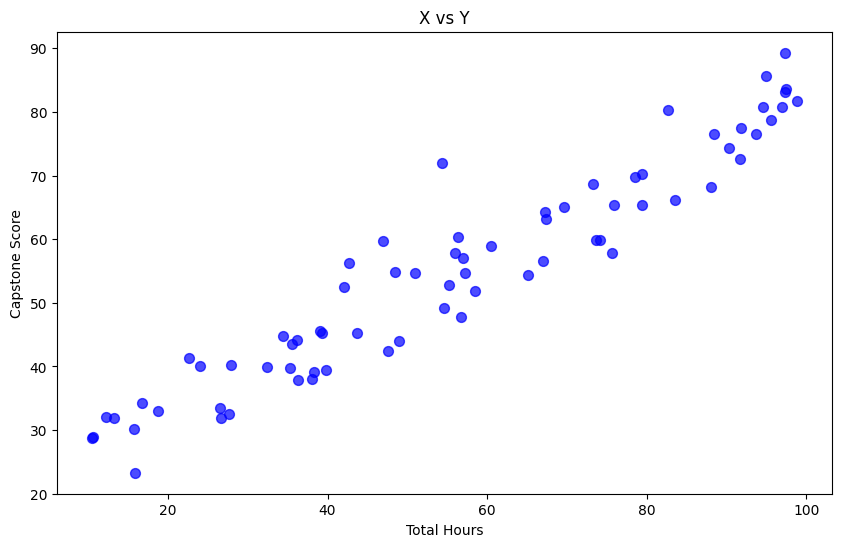

In [8]:
plt.figure(figsize=(10,6))
plt.scatter(X,Y, alpha=0.7, color='blue', s=50)
plt.xlabel('Total Hours')
plt.ylabel('Capstone Score')
plt.title('X vs Y')
plt.show()

In [9]:
def cost_compute(X,Y,beta):

    """
        X : (m,n)
        Y : (m,)
        beta : (beta0, beta1, beta2 )

        MSE => sum(y_hat - y) ** 2
        x.dot(beta) => beta0 + beta1.x1 + beta2.x2 + .......+betan.xn
    """




    m = len(Y)
    y_hat = X.dot(beta)
    cost = (1 / (2 * m)) * np.sum((y_hat - Y) ** 2)

    return cost

In [10]:
def gradient_descent(X, Y, beta, lr, n_itr):
    m = len(Y)
    cost_history = []
    
    for i in range(n_itr):
        y_hat = X.dot(beta)
        gradiant = (1 / m) * X.T.dot(y_hat - Y)

        beta = beta - lr * gradiant

        cost = cost_compute(X,Y,beta)
        cost_history.append(cost)

        if(i % 100 == 0):
            print(f"Iteration : {i} : Cost: {cost:.4f}")

    return cost_history, beta

In [11]:
X_with_bias = np.column_stack([np.ones((len(X))), X])
X_with_bias

array([[ 1. , 43.7],
       [ 1. , 95.6],
       [ 1. , 75.9],
       [ 1. , 24. ],
       [ 1. , 88. ],
       [ 1. , 97.3],
       [ 1. , 26.5],
       [ 1. , 57.2],
       [ 1. , 48.9],
       [ 1. , 36.2],
       [ 1. , 65.1],
       [ 1. , 22.6],
       [ 1. , 36.3],
       [ 1. , 51. ],
       [ 1. , 56.3],
       [ 1. , 15.9],
       [ 1. , 96.9],
       [ 1. , 18.8],
       [ 1. , 54.6],
       [ 1. , 91.8],
       [ 1. , 69.6],
       [ 1. , 38.1],
       [ 1. , 26.6],
       [ 1. , 97.3],
       [ 1. , 94.6],
       [ 1. , 27.6],
       [ 1. , 39.3],
       [ 1. , 34.4],
       [ 1. , 42.1],
       [ 1. , 35.3],
       [ 1. , 98.8],
       [ 1. , 27.9],
       [ 1. , 10.5],
       [ 1. , 73.6],
       [ 1. , 75.6],
       [ 1. , 79.4],
       [ 1. , 16.7],
       [ 1. , 39.8],
       [ 1. , 15.7],
       [ 1. , 67.4],
       [ 1. , 74.2],
       [ 1. , 78.5],
       [ 1. , 60.5],
       [ 1. , 79.4],
       [ 1. , 54.4],
       [ 1. , 57. ],
       [ 1. , 48.5],
       [ 1. ,

In [12]:
beta = np.random.randn(2)
print(f"beta values : {beta}")
lr = 0.000001
n_itr = 10000

beta values : [ 0.11250577 -1.16390881]


In [13]:
cost_history,beta = gradient_descent(X_with_bias, Y, beta, lr, n_itr)

Iteration : 0 : Cost: 8287.9449
Iteration : 100 : Cost: 3859.4628
Iteration : 200 : Cost: 1811.9722
Iteration : 300 : Cost: 865.3228
Iteration : 400 : Cost: 427.6428
Iteration : 500 : Cost: 225.2825
Iteration : 600 : Cost: 131.7214
Iteration : 700 : Cost: 88.4630
Iteration : 800 : Cost: 68.4619
Iteration : 900 : Cost: 59.2138
Iteration : 1000 : Cost: 54.9372
Iteration : 1100 : Cost: 52.9591
Iteration : 1200 : Cost: 52.0438
Iteration : 1300 : Cost: 51.6199
Iteration : 1400 : Cost: 51.4231
Iteration : 1500 : Cost: 51.3314
Iteration : 1600 : Cost: 51.2882
Iteration : 1700 : Cost: 51.2675
Iteration : 1800 : Cost: 51.2572
Iteration : 1900 : Cost: 51.2516
Iteration : 2000 : Cost: 51.2483
Iteration : 2100 : Cost: 51.2460
Iteration : 2200 : Cost: 51.2442
Iteration : 2300 : Cost: 51.2426
Iteration : 2400 : Cost: 51.2411
Iteration : 2500 : Cost: 51.2397
Iteration : 2600 : Cost: 51.2382
Iteration : 2700 : Cost: 51.2368
Iteration : 2800 : Cost: 51.2354
Iteration : 2900 : Cost: 51.2340
Iteration : 

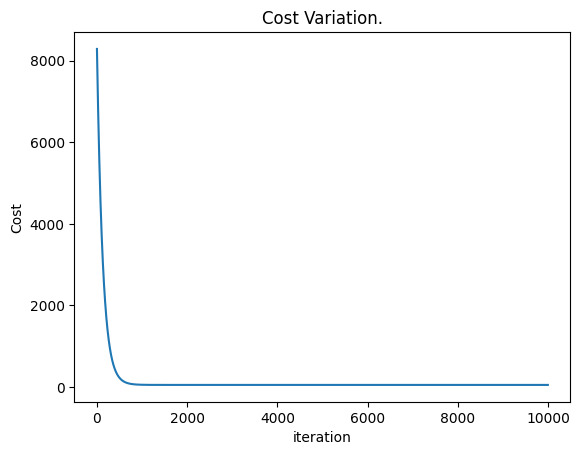

In [18]:
plt.plot(cost_history)
plt.title("Cost Variation.")
plt.xlabel("iteration")
plt.ylabel("Cost")
plt.show()

In [15]:
print(f"best values : {beta}")

best values : [0.18029492 0.91189989]


In [16]:
x_min, x_max = float(np.min(X)), float(np.max(X))
x_interval = np.linspace(x_min, x_max, 100)
x_interval_with_bias = np.column_stack([np.ones((len(x_interval))), x_interval])
y_hat_interval = x_interval_with_bias.dot(beta)
y_hat_interval

array([ 9.75524375, 10.56858476, 11.38192577, 12.19526678, 13.00860779,
       13.8219488 , 14.63528981, 15.44863083, 16.26197184, 17.07531285,
       17.88865386, 18.70199487, 19.51533588, 20.32867689, 21.14201791,
       21.95535892, 22.76869993, 23.58204094, 24.39538195, 25.20872296,
       26.02206398, 26.83540499, 27.648746  , 28.46208701, 29.27542802,
       30.08876903, 30.90211004, 31.71545106, 32.52879207, 33.34213308,
       34.15547409, 34.9688151 , 35.78215611, 36.59549712, 37.40883814,
       38.22217915, 39.03552016, 39.84886117, 40.66220218, 41.47554319,
       42.2888842 , 43.10222522, 43.91556623, 44.72890724, 45.54224825,
       46.35558926, 47.16893027, 47.98227128, 48.7956123 , 49.60895331,
       50.42229432, 51.23563533, 52.04897634, 52.86231735, 53.67565836,
       54.48899938, 55.30234039, 56.1156814 , 56.92902241, 57.74236342,
       58.55570443, 59.36904544, 60.18238646, 60.99572747, 61.80906848,
       62.62240949, 63.4357505 , 64.24909151, 65.06243252, 65.87

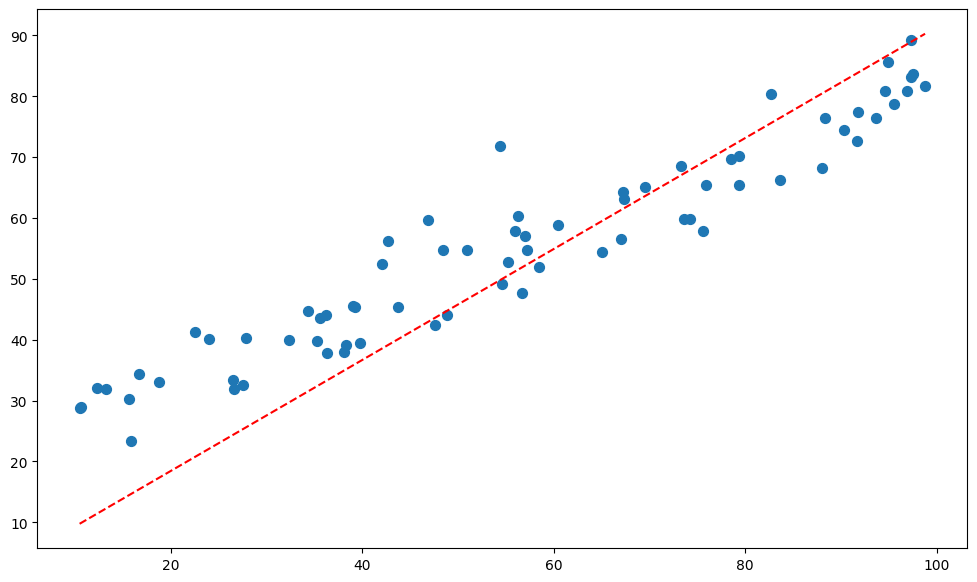

In [17]:
plt.figure(figsize=(12,7))

plt.scatter(X, Y, s = 50, label = "actual_data")
plt.plot(x_interval, y_hat_interval,'r--' , label = 'fitted line')
plt.show()